# Notebook 3 - The Watchlist 

This notebook turns the XGBoost out-of-fold probabilities into one of the project's  deliverables: a ranked watchlist of undesignated planning areas that most resemble Milieuschutz-designated ones. 

Working from the out-of-fold scores keeps every ranking honest, since each area was scored by a model that never saw its own district. After restricting to undesignated areas (y_true = 0), the distribution of scores is inspected to place a pragmatic cutoff, and the resulting shortlist is cross-checked against milieu_anteil, the continuous protected share, kept strictly out of the model as a feature and used here only to separate genuinely unprotected candidates from areas where some Milieuschutz already exists. 

The shortlist is then mapped across Berlin as an interpretive urgency layer (model similarity weighted by how little protection is already in place), and exported for the Cleanlab label-quality check in NB4 and for the dashboard. 

As throughout Module 2, the score expresses similarity to the existing designation pattern, not an objective probability of displacement. The undesignated areas surfacing near the top are precisely the early-warning candidates the platform is built to find.


In [1]:
#load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap


In [2]:
#load the XGBoost OOF probabilities set 
xgb_oof = pd.read_csv("../../models/M_oof_xgboost.csv", dtype={"plr_id": str})

#load dataset_0 for readable identifiers (plr_name, bez)
meta = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
meta = meta[["plr_id", "plr_name", "bez"]]

#zero-pad plr_id consistently (same convention as NB1/NB2)
for d in (xgb_oof, meta):   
    d["plr_id"] = d["plr_id"].astype(str).str.zfill(8)

#build the working table: XGBoost oof_prob + labels + names/district
df = xgb_oof.merge(meta, on="plr_id", how="left")

#sanity 
assert df["plr_name"].notna().all(), "some PLR did not get a name/Bezirk — check the merge"
assert len(df) == len(xgb_oof), "merge changed row count — duplicate plr_id?"
print(f"{len(df)} PLR | {int(df['y_true'].sum())} designated | "
      f"{int((df['y_true']==0).sum())} undesignated")

527 PLR | 109 designated | 418 undesignated


### Choosing the Length of the List 

To turn a continuous ranking into a finite shortlist, the out-of-fold probabilities of the undesignated areas are inspected for a natural break rather than an arbitrary threshold. 


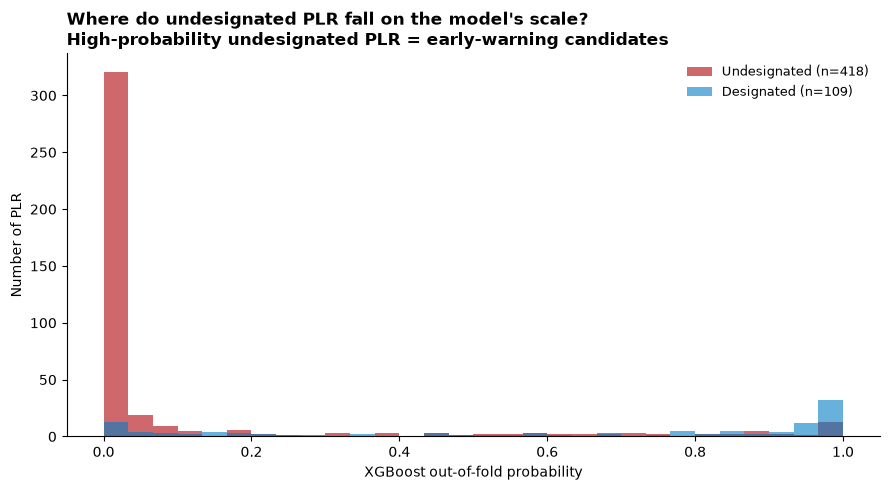

      plr_id                plr_name                              bez  oof_prob
0   01401044              Uferstraße                       01 - Mitte  0.999109
1   01300731           Koloniestraße                       01 - Mitte  0.997601
2   01100416             Arkonaplatz                       01 - Mitte  0.995976
3   07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
4   01200623             Stephankiez                       01 - Mitte  0.986148
5   01401049             Schulstraße                       01 - Mitte  0.985959
6   04501147       Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600
7   01300836   Humboldthain Nordwest                       01 - Mitte  0.984006
8   01200522      Elberfelder Straße                       01 - Mitte  0.983263
9   01200628       Lüneburger Straße                       01 - Mitte  0.979387
10  09200511       Griechischer Park            09 - Treptow-Köpenick  0.977478
11  01300834           Brunnenstraße    

In [3]:
#Distribution of XGBoost oof_prob, split by actual designation status
#Goal: where do undesignated PLR sit? Is there a natural cutoff for the watchlist that can be used?
desig   = df.loc[df["y_true"] == 1, "oof_prob"]
undesig = df.loc[df["y_true"] == 0, "oof_prob"]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 31)
ax.hist(undesig, bins=bins, alpha=0.6, color="#AE030C", label=f"Undesignated (n={len(undesig)})")
ax.hist(desig,   bins=bins, alpha=0.6, color="#027DC5", label=f"Designated (n={len(desig)})")
ax.set_xlabel("XGBoost out-of-fold probability", fontsize=10)
ax.set_ylabel("Number of PLR", fontsize=10)
ax.set_title("Where do undesignated PLR fall on the model's scale?\n"
             "High-probability undesignated PLR = early-warning candidates",
             fontsize=12, fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

#eyeball the top undesignated PLR to see where probabilities start dropping
top_undesig = (df[df["y_true"] == 0]
               .sort_values("oof_prob", ascending=False)
               [["plr_id", "plr_name", "bez", "oof_prob"]]
               .head(30)
               .reset_index(drop=True))
print(top_undesig.to_string())

### Result: the Length of the List 

The scores fall off gradually, but a visible step appears after the 25th-ranked area (oof_prob 0.824 → 0.767), which is adopted as a pragmatic cutoff. N = 25 is a length decision, not a statistical claim: it balances a list short enough to act on against one long enough to capture the clear look-alikes.

In [4]:
#Resemblance List: undesignated PLR the model ranks most designation-like
#Cutoff N=25, chosen at the visible probability drop (~0.82 -> 0.77 after rank 25)

N_WATCHLIST = 25

watchlist = (
    df[df["y_true"] == 0]
    .sort_values("oof_prob", ascending=False)
    .head(N_WATCHLIST)
    .reset_index(drop=True)
    [["plr_id", "plr_name", "bez", "oof_prob"]]
)
watchlist.index = watchlist.index + 1         
watchlist.index.name = "rank"

#document the cutoff: what prob does the last included PLR have, and the first excluded?
cutoff_in  = watchlist["oof_prob"].iloc[-1]
first_out  = (df[df["y_true"] == 0]
              .sort_values("oof_prob", ascending=False)
              ["oof_prob"].iloc[N_WATCHLIST])
print(f"Resemblance List: {N_WATCHLIST} undesignated PLR")
print(f"Cutoff: last included oof_prob = {cutoff_in:.3f} | first excluded = {first_out:.3f}")
print(f"District distribution:\n{watchlist['bez'].value_counts().to_string()}")
print()
print(watchlist.to_string())

Resemblance List: 25 undesignated PLR
Cutoff: last included oof_prob = 0.824 | first excluded = 0.767
District distribution:
bez
01 - Mitte                         12
04 - Charlottenburg-Wilmersdorf     4
07 - Tempelhof-Schöneberg           3
09 - Treptow-Köpenick               2
02 - Friedrichshain-Kreuzberg       1
03 - Pankow                         1
08 - Neukölln                       1
12 - Reinickendorf                  1

        plr_id                plr_name                              bez  oof_prob
rank                                                                             
1     01401044              Uferstraße                       01 - Mitte  0.999109
2     01300731           Koloniestraße                       01 - Mitte  0.997601
3     01100416             Arkonaplatz                       01 - Mitte  0.995976
4     07100206      Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505
5     01200623             Stephankiez                       01 - Mitte  0

## Result Discussion: the Resemblance List 

The 25 highest-ranked undesignated areas concentrate heavily in Mitte (12 of 25), with the remainder spread across Charlottenburg-Wilmersdorf, Tempelhof-Schöneberg and six other districts. Thats an inner-city clustering consistent with the early-warning thesis. 

Cross-checking against milieu_anteil, however, shows the raw resemblance ranking is not yet an action list: several top areas (Uferstraße 0.49, Großgörschenstraße 0.50) are already near the 50% majority threshold, so their high score partly reflects existing protection rather than an unprotected look-alike. This motivates a second layer that discounts resemblance by how much protection is already in place.

## Creating an urgency variable

Because resemblance alone rewards areas that are already partly protected, an urgency score is introduced: oof_prob × (1 − milieu_anteil), combining "looks designated" with "still unprotected" into one priority. 

This is explicitly a filtering device, not a model prediction. The variable "milieu_anteil" never enters the model as a feature and is used here only to reweight the ranking. The continuous share is drawn from the target notebook, where a value of zero is an observed "no protection", not a missing value.

In [ ]:
#check: among areas the model flags, where is the early-warning value highest?

labels_full = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
labels_full["plr_id"] = labels_full["plr_id"].astype(str).str.zfill(8)

#pull milieu_anteil onto the watchlist
watchlist_checked = watchlist.merge(
    labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left"
)
watchlist_checked.index = watchlist_checked.index + 1
watchlist_checked.index.name = "rank"


print(watchlist_checked[["plr_name", "bez", "oof_prob", "milieu_anteil"]].to_string())

                    plr_name                              bez  oof_prob  milieu_anteil
rank                                                                                  
1                 Uferstraße                       01 - Mitte  0.999109       0.487524
2              Koloniestraße                       01 - Mitte  0.997601       0.221120
3                Arkonaplatz                       01 - Mitte  0.995976       0.000959
4         Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505       0.495631
5                Stephankiez                       01 - Mitte  0.986148       0.383226
6                Schulstraße                       01 - Mitte  0.985959       0.238271
7          Leon-Jessel-Platz  04 - Charlottenburg-Wilmersdorf  0.984600       0.000000
8      Humboldthain Nordwest                       01 - Mitte  0.984006       0.129641
9         Elberfelder Straße                       01 - Mitte  0.983263       0.000026
10         Lüneburger Straße               

## Result 

Adding the variable milieu_anteil lets us see that some of the very high lookalikes are nearly 50% protected. This is why we create a variable that states clearly whether they are protected, partially protected or not. 

In [6]:
#Refine: milieu_anteil > 0 is too coarse. Split by how much protection already exists
def classify(a):
    if a < 0.10:
        return "effectively unprotected"      # early-warning candidate
    elif a < 0.40:
        return "partially protected"          # protection started, substantial gap
    else:
        return "near-designated"              # just below the 50% majority threshold

watchlist_checked["status"] = watchlist_checked["milieu_anteil"].apply(classify)
print(watchlist_checked["status"].value_counts().to_string(), "\n")
print(watchlist_checked[["plr_name", "bez", "oof_prob", "milieu_anteil", "status"]].to_string())

status
partially protected        10
effectively unprotected    10
near-designated             5 

                    plr_name                              bez  oof_prob  milieu_anteil                   status
rank                                                                                                           
1                 Uferstraße                       01 - Mitte  0.999109       0.487524          near-designated
2              Koloniestraße                       01 - Mitte  0.997601       0.221120      partially protected
3                Arkonaplatz                       01 - Mitte  0.995976       0.000959  effectively unprotected
4         Großgörschenstraße        07 - Tempelhof-Schöneberg  0.992505       0.495631          near-designated
5                Stephankiez                       01 - Mitte  0.986148       0.383226      partially protected
6                Schulstraße                       01 - Mitte  0.985959       0.238271      partially protected
7    

## The Resemblance Map of Berlin 

The watchlist is mapped across all 542 planning areas to see where the look-alike candidates sit spatially. Undesignated areas are shaded by their model score; already-designated and non-modelled areas (the 15 low-density PLR excluded from dataset_0) are left grey. 

The map is read as a similarity surface, not a probability of displacement.

In [7]:
gdf = gpd.read_file("../../data/real_estate/Geodata/PLR_raw.geojson")
gdf["plr_id"] = gdf["plr_id"].astype(str).str.zfill(8)

print("Spalten:", gdf.columns.tolist())
print("CRS:", gdf.crs)
print("Zeilen:", len(gdf))
print(gdf.drop(columns="geometry").head(3).to_string())

Spalten: ['id', 'plr_id', 'plr_name', 'bzr_id', 'bzr_name', 'pgr_id', 'pgr_name', 'bez', 'finhalt', 'stadtraum_id', 'stadtraum_name', 'stand', 'geometry']
CRS: EPSG:25833
Zeilen: 542
                        id    plr_id           plr_name  bzr_id        bzr_name pgr_id pgr_name         bez       finhalt stadtraum_id stadtraum_name       stand
0  a_lor_plr_2021.01100101  01100101       Stülerstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.669331e+05            1   Innere Stadt  01.01.2021
1  a_lor_plr_2021.01100102  01100102  Großer Tiergarten  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  3.919852e+06            1   Innere Stadt  01.12.2021
2  a_lor_plr_2021.01100103  01100103       Lützowstraße  011001  Tiergarten Süd   0110  Zentrum  01 - Mitte  5.471832e+05            1   Innere Stadt  01.12.2021


In [8]:
#Merge model output onto PLR geometries; milieu_anteil pulled in SEPARATELY (interpretation only, never a feature)

#labels_full holds milieu_anteil (from target_milieuschutz.csv) — kept out of df on purpose
plot_geo1 = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true"]], on="plr_id", how="left")
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 1: Plot watchlist for all with protected areas <50%
undes1 = (plot_geo1["y_true"] == 0)
plot_geo1["watchlist"] = np.nan
plot_geo1.loc[undes1, "watchlist"] = (
    plot_geo1.loc[undes1, "oof_prob"])


#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch1 = plot_geo1["oof_prob"].isna().sum()
print(f"{len(plot_geo1)} geometries | {n_nomatch1} without a model row (dropped/uninhabited PLR)")


542 geometries | 15 without a model row (dropped/uninhabited PLR)


In [9]:
#labels_full holds milieu_anteil (from target_milieuschutz.csv) — kept out of df on purpose
plot_geo2 = (
    gdf
    .merge(df[["plr_id", "oof_prob", "y_true", "plr_name"]], on="plr_id", how="left")
    .merge(labels_full[["plr_id", "milieu_anteil"]], on="plr_id", how="left")
)

#Plot 2: urgency only for UNDESIGNATED PLR; designated + non-modelled stay NaN (grey)
undes2 = (plot_geo2["y_true"] == 0)
plot_geo2["urgency"] = np.nan
plot_geo2.loc[undes2, "urgency"] = (
    plot_geo2.loc[undes2, "oof_prob"] * (1 - plot_geo2.loc[undes2, "milieu_anteil"])
)

#diagnostics: how many geometries got no model row (the ~15 dropped PLR)?
n_nomatch2 = plot_geo2["oof_prob"].isna().sum()
print(f"{len(plot_geo2)} geometries | {n_nomatch2} without a model row (dropped/uninhabited PLR)")
print(f"urgency range: {plot_geo2['urgency'].min():.3f} – {plot_geo2['urgency'].max():.3f}")

542 geometries | 15 without a model row (dropped/uninhabited PLR)
urgency range: 0.000 – 0.995


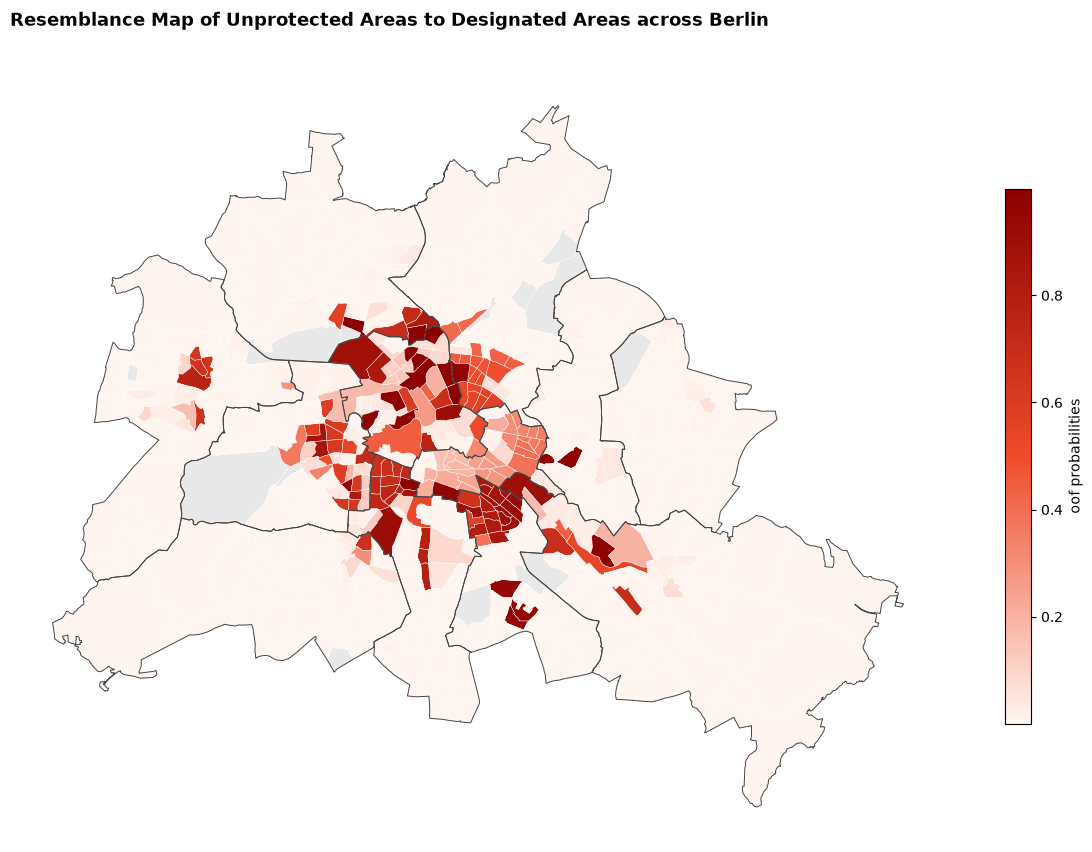

In [11]:
#plot1 the resemblance map 
#which undesignated PLR most resemble designated ones

red_cmap = LinearSegmentedColormap.from_list("kiez_red", ["#FFF5F0", "#EE4B2B", "#8B0000"])


fig, ax = plt.subplots(figsize=(12, 11))

#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo1.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo1[plot_geo1["y_true"] == 1].plot(
    ax=ax, cmap=red_cmap, edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured by urgency (white -> red)
plot_geo1[undes1].plot(
    ax=ax, cmap=red_cmap, edgecolor="white", linewidth=0.3,
    legend=True, column="oof_prob", legend_kwds={"label": "oof probabilities",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Resemblance Map of Unprotected Areas to Designated Areas across Berlin\n",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_resemblance_map.png", dpi=200, bbox_inches="tight")
plt.show()

## The Watchlist (resemblance × unprotected share)



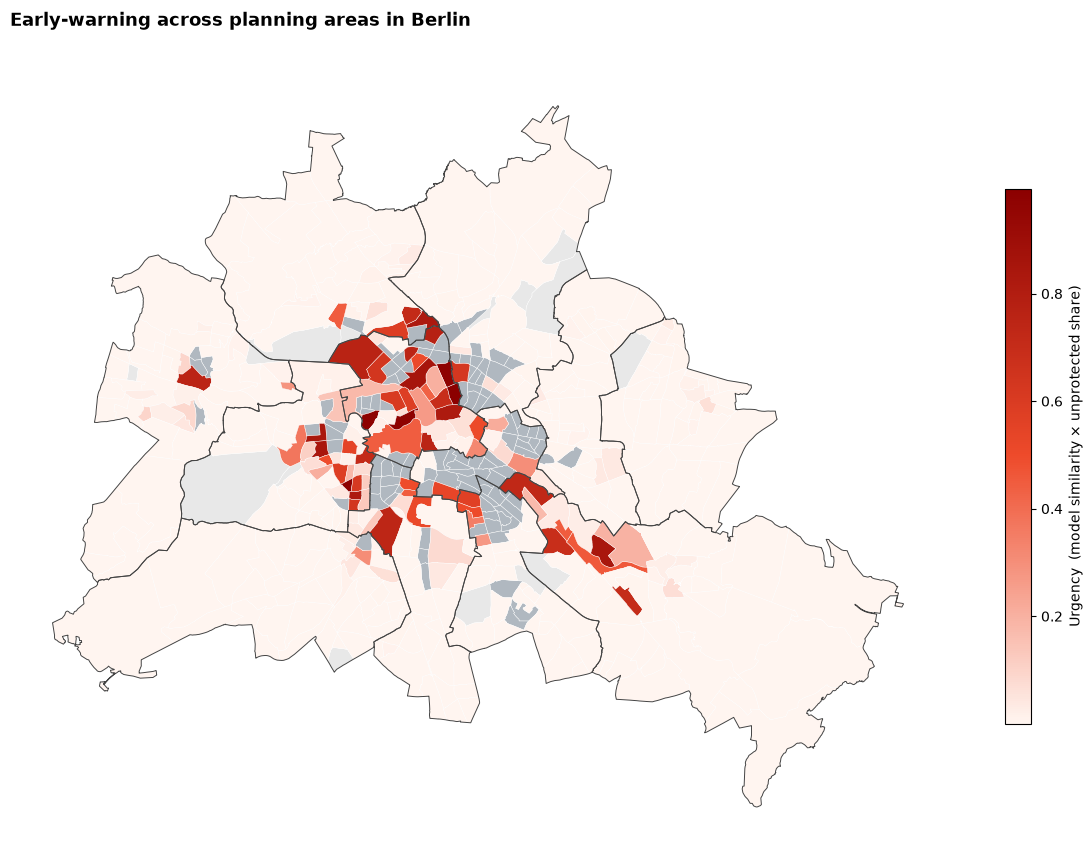

In [12]:
#plot2: urgency as model similarity x unprotected share 
#where is the early-warning value highest" — high similarity and little existing protection
fig, ax = plt.subplots(figsize=(12, 11))
red_cmap = LinearSegmentedColormap.from_list("kiez_red", ["#FFF5F0", "#EE4B2B", "#8B0000"])


#layer 1: all PLR as light grey base (so dropped + designated areas are visible, not holes)
plot_geo2.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.3)

#layer 2: designated PLR in a distinct neutral (already protected — not "urgent")
plot_geo2[plot_geo2["y_true"] == 1].plot(
    ax=ax, color="#b0b8c0", edgecolor="white", linewidth=0.3
)

#layer 3: undesignated PLR coloured by urgency (white -> red)
plot_geo2[undes2].plot(
    ax=ax, column="urgency", cmap=red_cmap, edgecolor="white", linewidth=0.3,
    legend=True, legend_kwds={"label": "Urgency  (model similarity × unprotected share)",
                              "shrink": 0.5}
)

#Bezirk outlines so the weak-fold districts are locatable
gdf.dissolve("bez").boundary.plot(ax=ax, color="#444444", linewidth=0.7)

ax.set_title("Early-warning across planning areas in Berlin\n",
             fontsize=13, fontweight="bold", loc="left")
ax.axis("off")
plt.tight_layout()
plt.savefig("../../plots/Module2/M2_watchlist1.png", dpi=200, bbox_inches="tight")
plt.show()

## Result 

The urgency layer reweights the resemblance score by the unprotected share, so areas that merely sit near the 50% threshold recede and genuinely unprotected look-alikes rise. 

The candidates cluster in the inner-city ring directly around the existing grey (already-protected) areas — Kreuzberg, Neukölln, Friedrichshain and the corridor toward the south-east — rather than at the city edge. That spatial pattern is exactly what the early-warning thesis predicts and serves as a plausibility check on the map.

## Comparison of the two Lists 

The two rankings — raw resemblance (oof_prob) and protection-discounted urgency — agree on most areas but diverge on seven: seven PLR that the resemblance list includes are pushed out of the urgency top-25, and seven different ones enter. 

The areas leaving are the near-designated cases (milieu_anteil around 0.4–0.5) whose scores the discount deliberately shrinks. The areas entering are lower-resemblance but essentially unprotected. This ~7-of-25 shift is the practical footprint of the urgency reweighting.

In [13]:
#how are the two lists differing? 

sub = plot_geo2[undes2].copy()
sub["rank_prob"] = sub["oof_prob"].rank(ascending=False)
sub["rank_urg"]  = sub["urgency"].rank(ascending=False)

wl = sub.nsmallest(25, "rank_prob")          # the actual watchlist
print(wl[["oof_prob", "milieu_anteil", "urgency"]]
      .assign(shift=wl["rank_prob"] - wl["rank_urg"])
      .sort_values("shift", key=abs, ascending=False)
      .head(10))

# does urgency pull anyone INTO the top 25 who wasn't there by oof_prob?
in_prob = set(sub.nsmallest(25, "rank_prob").index)
in_urg  = set(sub.nsmallest(25, "rank_urg").index)
entrants = sorted(in_urg - in_prob)          
print("only in oof top25:", sorted(in_prob - in_urg))
print("only in urgency top25:", entrants)

     oof_prob  milieu_anteil   urgency  shift
43   0.999109       0.487524  0.512020  -36.0
292  0.992505       0.495631  0.500588  -36.0
22   0.986148       0.383226  0.608231  -24.0
300  0.871418       0.484008  0.449644  -24.0
59   0.975650       0.453041  0.533641  -22.0
336  0.893927       0.434770  0.505274  -21.0
160  0.862824       0.018465  0.846893   15.0
194  0.823657       0.000000  0.823657   14.0
507  0.824959       0.000000  0.824959   14.0
126  0.963523       0.348877  0.627372  -13.0
only in oof top25: [22, 43, 59, 126, 292, 300, 336]
only in urgency top25: [4, 14, 186, 213, 384, 396, 508]


7 PLRs switch sides, which ones come in in the urgency watchlist? Do they also come from the weak fold (Charlottenburg-Wilmersdorf and Lichtenberg)? 

In [14]:
#build sub FIRST
sub = plot_geo2[undes2].copy()

#strip the "NN - " prefix
sub["bez_name"] = sub["bez"].str.split(" - ").str[-1].str.strip()

#define what counts as weak fold
weak_fold_names = ["Charlottenburg-Wilmersdorf", "Lichtenberg"]

#pick the entrants and include bez_name in the columns
cols = ["bez", "bez_name", "oof_prob", "milieu_anteil", "urgency"]
entrant_rows = sub.loc[entrants, cols].copy()

#match on bez_name (stripped), NOT bez (prefixed)
entrant_rows["weak_fold"] = entrant_rows["bez_name"].isin(weak_fold_names)

entrant_rows = entrant_rows.sort_values("oof_prob", ascending=False)
print("only in urgency top25:", entrants)
print(entrant_rows)
print(f"\n{entrant_rows['weak_fold'].sum()} of {len(entrant_rows)} entrants sit in the weak fold")

only in urgency top25: [4, 14, 186, 213, 384, 396, 508]
                                 bez                    bez_name  oof_prob  \
213                     05 - Spandau                     Spandau  0.766517   
4                         01 - Mitte                       Mitte  0.756666   
186  04 - Charlottenburg-Wilmersdorf  Charlottenburg-Wilmersdorf  0.712941   
508               12 - Reinickendorf               Reinickendorf  0.712730   
396            09 - Treptow-Köpenick            Treptow-Köpenick  0.704122   
14                        01 - Mitte                       Mitte  0.693884   
384            09 - Treptow-Köpenick            Treptow-Köpenick  0.689616   

     milieu_anteil   urgency  weak_fold  
213   1.801573e-02  0.752708      False  
4     2.602949e-08  0.756666      False  
186   5.816938e-09  0.712941       True  
508   0.000000e+00  0.712730      False  
396   0.000000e+00  0.704122      False  
14    0.000000e+00  0.693884      False  
384   0.000000e+00  0.689

### Results 

The final watchlist is the union of both top-25 lists — 32 areas in total — with provenance flags recording whether each entered via resemblance, urgency, or both. Of the seven urgency entrants, only one falls in the weak Charlottenburg-Wilmersdorf/Lichtenberg fold; it is retained rather than excluded, since the weak fold is a data property, not a disqualifier, though its oof_prob (high-0.60s) sits at the lower end of the list and should be read with that caveat. 

The candidates lie almost entirely inner-city, adjacent to already-protected areas — a strong sanity signal that the map is plausible. Because the urgency surface looks so convincing, it bears repeating that it is a derived interpretive score (resemblance × unprotected share), not a direct model output. Grey areas are either already designated or not modelled.

In [15]:
#Export the watchlist for NB4 Cleanlab validation + dashboard
#Both rankings (oof_prob + urgengy flag) are taken side by side - why? 
#so neither ranking has gaps. rank_* is NaN when a PLR isn't in that top-25.

N_WATCHLIST = 25

# full undesignated set with both scores (from plot_geo2, which has urgency)
und = plot_geo2[undes2].copy()
und = und.merge(df[["plr_id", "plr_name"]], on="plr_id", how="left")   
und["urgency"] = und["oof_prob"] * (1 - und["milieu_anteil"])  

#rank both ways (1 = most designation-like / most urgent)
und["rank_oof"] = und["oof_prob"].rank(ascending=False, method="min").astype(int)
und["rank_urgency"] = und["urgency"].rank(ascending=False, method="min").astype(int)

#membership = union of the two top-25s
in_oof = und["rank_oof"] <= N_WATCHLIST
in_urg_mask = und["rank_urgency"] <= N_WATCHLIST  
watchlist_out = und[in_oof | in_urg_mask].copy()

#blank ranks outside each top-25 — read from watchlist_out's OWN columns, no mask
watchlist_out.loc[watchlist_out["rank_oof"]     > N_WATCHLIST, "rank_oof"]     = pd.NA
watchlist_out.loc[watchlist_out["rank_urgency"] > N_WATCHLIST, "rank_urgency"] = pd.NA

#provenance flags follow from which rank survived
watchlist_out["in_oof_top25"]     = watchlist_out["rank_oof"].notna()
watchlist_out["in_urgency_top25"] = watchlist_out["rank_urgency"].notna()


#add descriptive status tag (three-way classify), attached from milieu_anteil
watchlist_out["status"] = watchlist_out["milieu_anteil"].apply(classify)

#order the file by urgency (headline), oof_prob as tiebreak; keep both rank cols
watchlist_out = (
    watchlist_out
    .sort_values(["rank_urgency", "rank_oof"], na_position="last")
    [["plr_id", "plr_name", "bez", "oof_prob", "urgency",
      "milieu_anteil", "status", "rank_oof", "rank_urgency",
      "in_oof_top25", "in_urgency_top25"]]
    .reset_index(drop=True)
)

watchlist_out.to_csv("../../models/M2_watchlist2.csv", index=False)
print(f"exported {len(watchlist_out)} PLR "
      f"(union of oof_prob top-{N_WATCHLIST} and urgency top-{N_WATCHLIST}) -> M2_watchlist2.csv")
print(watchlist_out.to_string(index=False))

exported 32 PLR (union of oof_prob top-25 and urgency top-25) -> M2_watchlist2.csv
  plr_id               plr_name                             bez  oof_prob  urgency  milieu_anteil                  status  rank_oof  rank_urgency  in_oof_top25  in_urgency_top25
01100416            Arkonaplatz                      01 - Mitte  0.995976 0.995020   9.594333e-04 effectively unprotected       3.0           1.0          True              True
04501147      Leon-Jessel-Platz 04 - Charlottenburg-Wilmersdorf  0.984600 0.984600   0.000000e+00 effectively unprotected       7.0           2.0          True              True
01200522     Elberfelder Straße                      01 - Mitte  0.983263 0.983237   2.635215e-05 effectively unprotected       9.0           3.0          True              True
01200628      Lüneburger Straße                      01 - Mitte  0.979387 0.979387   0.000000e+00 effectively unprotected      10.0           4.0          True              True
01300834          Brunnenst

### Caveats — and how we validate against them

Two caveats apply to the urgency score. First, oof_prob and milieu_anteil are correlated by construction: the model is trained to predict designation (milieu_anteil > 0.5), so a PLR at 0.49 scores high precisely because it sits near the designation pattern, and urgency then multiplies that high score by a small (1 − 0.49). 

Under a filtering framing this is not a flaw but the intent — deliberately combining "looks designated" with "still unprotected" into one priority — but the two factors should not be read as independent signals confirming each other. Second, the 0.50 threshold is a hard gate: an area at 0.49 is scored, at 0.51 it drops off entirely; this is a defensible scope decision (majority-protected areas are outside the action space), and the (1 − milieu_anteil) weighting further encodes a contestable policy judgment — that urgency falls linearly with existing protection.

The practical stance is therefore to keep oof_prob as the primary, statistically grounded ranking and treat urgency as an explicitly labelled interpretive filter, not a model output. 

Next, we will cross-check and validate our findings with two independent checks: the library cleanlab in Notebook 4 will audit the labels themselves. A regression cross-check in notebook 5 will re-derive the ranking from the continuous milieu_anteil instead of the binary label.